In [31]:
import seaborn as sns
import pandas as pd
import matplotlib as mb
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc

In [32]:
from matplotlib.font_manager import get_font_names
print(get_font_names())

['cmr10', 'STIXSizeFourSym', 'cmb10', 'cmmi10', 'Ubuntu', 'Ubuntu Mono', 'DejaVu Sans Display', 'STIXSizeFiveSym', 'DejaVu Serif Display', 'cmsy10', 'STIXSizeOneSym', 'cmex10', 'STIXSizeThreeSym', 'cmtt10', 'cmss10', 'STIXNonUnicode', 'STIXGeneral', 'DejaVu Sans Mono', 'Inconsolata', 'DejaVu Serif', 'Ubuntu Condensed', 'Source Code Pro', 'DejaVu Sans', 'STIXSizeTwoSym']


In [33]:
ctrl_df = pd.read_csv('CalcTranData.csv')
ank_df = pd.read_csv('CalcTranDataAnk.csv')

In [34]:
# Get all columns starting with 'Fura_' in ank_df
ank_fura_columns = [col for col in ank_df.columns if col.startswith('Fura_')]

# Step 1: Melt the 'ctrl' dataframe
ctrl_df_long = pd.melt(ctrl_df, id_vars=['Time', 'Group'], value_vars=[f'Fura_{i}' for i in range(1, 8)],
                       var_name='Fura_ID', value_name='Intracellular_Calcium')

# Step 2: Melt the 'ank' dataframe, using dynamically selected Fura_* columns
ank_df_long = pd.melt(ank_df, id_vars=['Time', 'Group'], value_vars=ank_fura_columns,
                      var_name='Fura_ID', value_name='Intracellular_Calcium')

In [35]:
# Step 3: Combine the two long-format dataframes
combined_df = pd.concat([ctrl_df_long, ank_df_long], ignore_index=True)

In [36]:
print(combined_df)

       Time Group  Fura_ID  Intracellular_Calcium
0     0.000  ctrl   Fura_1                  0.912
1     0.004  ctrl   Fura_1                  0.918
2     0.008  ctrl   Fura_1                  0.911
3     0.012  ctrl   Fura_1                  0.906
4     0.016  ctrl   Fura_1                  0.913
...     ...   ...      ...                    ...
3327  0.932   ank  Fura_17                  1.087
3328  0.936   ank  Fura_17                  1.088
3329  0.940   ank  Fura_17                  1.091
3330  0.944   ank  Fura_17                  1.092
3331  0.948   ank  Fura_17                  1.089

[3332 rows x 4 columns]


In [37]:
# Step 2: Group by 'Time' and 'Group', and compute the average of 'Measurement'
averages_df = combined_df.groupby(['Time', 'Group'])['Intracellular_Calcium'].mean().reset_index()

In [38]:
print(averages_df)

      Time Group  Intracellular_Calcium
0    0.000   ank               1.057143
1    0.000  ctrl               0.852000
2    0.004   ank               1.057857
3    0.004  ctrl               0.852286
4    0.008   ank               1.054857
..     ...   ...                    ...
471  0.940  ctrl               0.861571
472  0.944   ank               1.065000
473  0.944  ctrl               0.861000
474  0.948   ank               1.062000
475  0.948  ctrl               0.860143

[476 rows x 3 columns]


In [39]:
combined_df.to_csv('combined_data.csv', index=False)
averages_df.to_csv('averages_data.csv', index=False)

In [53]:
sns.set_theme(  style ="whitegrid")


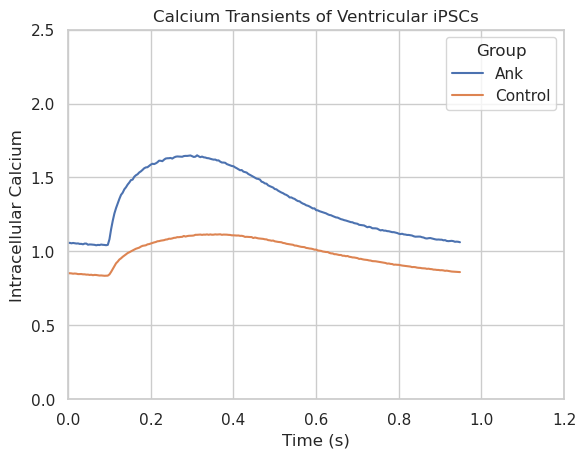

In [63]:
sns.lineplot(x="Time", y="Intracellular_Calcium",
             hue="Group", 
                       data=averages_df)

plt.title("Calcium Transients of Ventricular iPSCs")
plt.xlabel("Time (s)")  # Set the label for the x-axis
plt.ylabel("Intracellular Calcium")  # Set the label for the y-axis



# Set x-axis and y-axis limits
plt.xlim(0, 1.2)  # For example, limit x-axis from 0 to 100
plt.ylim(0,2.5)   # For example, limit y-axis from 0 to 10

# Retrieve current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()


# Define a dictionary for the label mapping
label_mapping = {
    "ank": "Ank",
    "ctrl": "Control",
    
}

# Apply the mapping to the labels
labels = [label_mapping.get(label, label) for label in labels]

# Update the legend with the modified labels
plt.legend(handles=handles, labels=labels, title="Group")

plt.savefig("calcium_transients_plot.png", dpi=300) 

plt.show()